In [2]:
import numpy as np
import matplotlib.pyplot as plt
from numba import cuda, float64, complex128
from numba.cuda import jit as cuda_jit
import math

import few

from few.trajectory.inspiral import EMRIInspiral
from few.trajectory.ode import KerrEccEqFlux
from few.amplitude.ampinterp2d import AmpInterpKerrEccEq
from few.summation.interpolatedmodesum import InterpolatedModeSum 


from few.utils.ylm import GetYlms

from few import get_file_manager

from few.waveform import GenerateEMRIWaveform, FastKerrEccentricEquatorialFlux

from few.utils.geodesic import get_fundamental_frequencies

from few.utils.constants import YRSID_SI
from smt.sampling_methods import LHS


import os
import sys

# Changing directory to FEWNEW/work
# to import stuffs
os.chdir('/home/svu/e1498138/emri_search/work/')
sys.path.insert(0, '/home/svu/e1498138/emri_search/work/')

import GWfuncs
import loglike_timemax  # TIME-MAXIMIZED VERSION
# import modeselectoralt
import parismc
# import gc
import pickle
import cupy as cp

# tune few configuration
cfg_set = few.get_config_setter(reset=True)
cfg_set.set_log_level("info")

# GPU configuration 
use_gpu = True
force_backend = "cuda12x"  
dt = 10     # Time step
T = 3/12     # Total time
print(f"Using dt = {dt} seconds, T = {T} years")

print('Initializing waveform generator...')
# keyword arguments for inspiral generator 
inspiral_kwargs={
        "func": 'KerrEccEqFlux',
        "DENSE_STEPPING": 0, #change to 1/True for uniform sampling
        "include_minus_m": False, 
}

# keyword arguments for inspiral generator 
amplitude_kwargs = {
    "force_backend": force_backend # Force GPU
}

# keyword arguments for Ylm generator (GetYlms)
Ylm_kwargs = {
    "force_backend": force_backend,  # Force GPU
    # "assume_positive_m": True  # if we assume positive m, it will generate negative m for all m>0
}

# keyword arguments for summation generator (InterpolatedModeSum)
sum_kwargs_comb = {
    "force_backend": force_backend,  # Force GPU
    "pad_output": True,
}

sum_kwargs_sep = {
    "force_backend": force_backend,  # Force GPU
    "pad_output": True,
    "separate_modes": True,
}

print("Creating GenerateEMRIWaveform class...")
# Kerr eccentric flux
waveform_gen_comb = GenerateEMRIWaveform(
    FastKerrEccentricEquatorialFlux, 
    frame='detector',
    inspiral_kwargs=inspiral_kwargs, 
    amplitude_kwargs=amplitude_kwargs, 
    Ylm_kwargs=Ylm_kwargs,
    sum_kwargs=sum_kwargs_comb,
    use_gpu=use_gpu
)

# Kerr eccentric flux
waveform_gen_sep = GenerateEMRIWaveform(
    FastKerrEccentricEquatorialFlux, 
    frame='detector',
    inspiral_kwargs=inspiral_kwargs, 
    amplitude_kwargs=amplitude_kwargs, 
    Ylm_kwargs=Ylm_kwargs,
    sum_kwargs=sum_kwargs_sep,
    use_gpu=use_gpu
)


print('Done initializing waveform generator.')

print("Creating GravWaveAnalysis class...")
gwf = GWfuncs.GravWaveAnalysis(T, dt)

print("Initializing loglike class...")


# Source parameters
m1 = 1e6
m2 = 1e1
a = 0.7
p0 = 9
e0 = 0.4
xI0 = 1.0
dist = 1.8  # Gpc
qS = np.pi
phiS = 0.
qK =  0.
phiK = 0.
Phi_phi0 = 0.4
Phi_theta0 = 0.0
Phi_r0 = 0.5

params_star = (m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0)
param_true = [np.log10(m1), np.log10(m2), a, p0, e0]

# n-indexed mode selection parameters
n_vals = np.arange(-1,6)  # n from -1 to 5
ell = 2  # quadrupole only

# NOTE: change verbose argument for debugging
# Using n-indexed mode selection
loglike_obj = loglike_timemax.LogLike(
    params_star,
    waveform_gen_comb,
    gwf,
    verbose=False,
    waveform_gen_sep=waveform_gen_sep,
    ell=ell,
    n_vals=n_vals,
    M_mode=None  # No SNR filtering, use all n-groups
)

print('Done initializing loglike class.')
print('Calculating SNR...')
data = loglike_obj.signal
data_snr = gwf.rhostat(data)
print('SNR calculated:', data_snr)
print("Setting up log_density and prior functions...")

# REVERSE TEMP for annealing
# supposed to be 1/10 if we're going with the right nomenclature 
# so supposed to be reversetemp
S = 1
def log_density(params):
    params = np.asarray(params)

    n_samples = params.shape[0] 
    log_likes = np.zeros(n_samples)


    for i in range(n_samples):
        logm1, logm2, a, p0, e0 = params[i]
        m1 = 10**logm1
        m2 = 10**logm2

        try:
            # NOTE: scaled by reverse temp
            loglike = S*loglike_obj(np.array([m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]))
        except Exception:
            loglike = -np.inf
        log_likes[i] = loglike

    return log_likes

def prior_transform(u):
    logm1lim = [5.6, 6.4]
    logm2lim = [0.8,1.3]
    alim = [0.3, 0.99]
    p0lim = [8.0, 11.0]
    e0lim = [0.2, 0.5]

    transformed = np.zeros_like(u)

    # Uniform in log for masses

    # m1
    transformed[:, 0] = (logm1lim[1] - logm1lim[0]) * u[:, 0] + logm1lim[0]

    # m2
    transformed[:, 1] = (logm2lim[1] - logm2lim[0]) * u[:, 1] + logm2lim[0]

    # Linear in others 

    # a
    transformed[:, 2] = (alim[1] - alim[0]) * u[:, 2] + alim[0]

    # p0
    transformed[:, 3] = (p0lim[1] - p0lim[0]) * u[:, 3] + p0lim[0] 

    # e0
    transformed[:, 4] = (e0lim[1] - e0lim[0]) * u[:, 4] + e0lim[0]

    
    return transformed

def inverse_prior_transform(params):
    logm1lim = [5.6, 6.4]
    logm2lim = [0.8, 1.3]
    alim = [0.3, 0.99]
    p0lim = [8.0, 11.0]
    e0lim = [0.2, 0.5]

    params = np.asarray(params)
    u = np.zeros_like(params)

    u[:, 0] = (params[:, 0] - logm1lim[0]) / (logm1lim[1] - logm1lim[0])
    u[:, 1] = (params[:, 1] - logm2lim[0]) / (logm2lim[1] - logm2lim[0])
    u[:, 2] = (params[:, 2] - alim[0]) / (alim[1] - alim[0])
    u[:, 3] = (params[:, 3] - p0lim[0]) / (p0lim[1] - p0lim[0])
    u[:, 4] = (params[:, 4] - e0lim[0]) / (e0lim[1] - e0lim[0])

    return u

print('Done setting up log-likelihood and prior.')

Using dt = 10 seconds, T = 0.25 years
Initializing waveform generator...
Creating GenerateEMRIWaveform class...
Done initializing waveform generator.
Creating GravWaveAnalysis class...
Initializing loglike class...
Done initializing loglike class.
Calculating SNR...
SNR calculated: 5.942134448355127
Setting up log_density and prior functions...
Done setting up log-likelihood and prior.


In [3]:
maxld_pt1=np.array([[6.00428558, 1.00036002, 0.7101336 , 8.94251488, 0.3992983 ]])


In [4]:
param_ranges = [(5.6,6.4),
                (0.8,1.3),
                (0.3,0.99),
                (8.0,11.0),
                (0.2,0.5)
                ]
param_ranges

[(5.6, 6.4), (0.8, 1.3), (0.3, 0.99), (8.0, 11.0), (0.2, 0.5)]

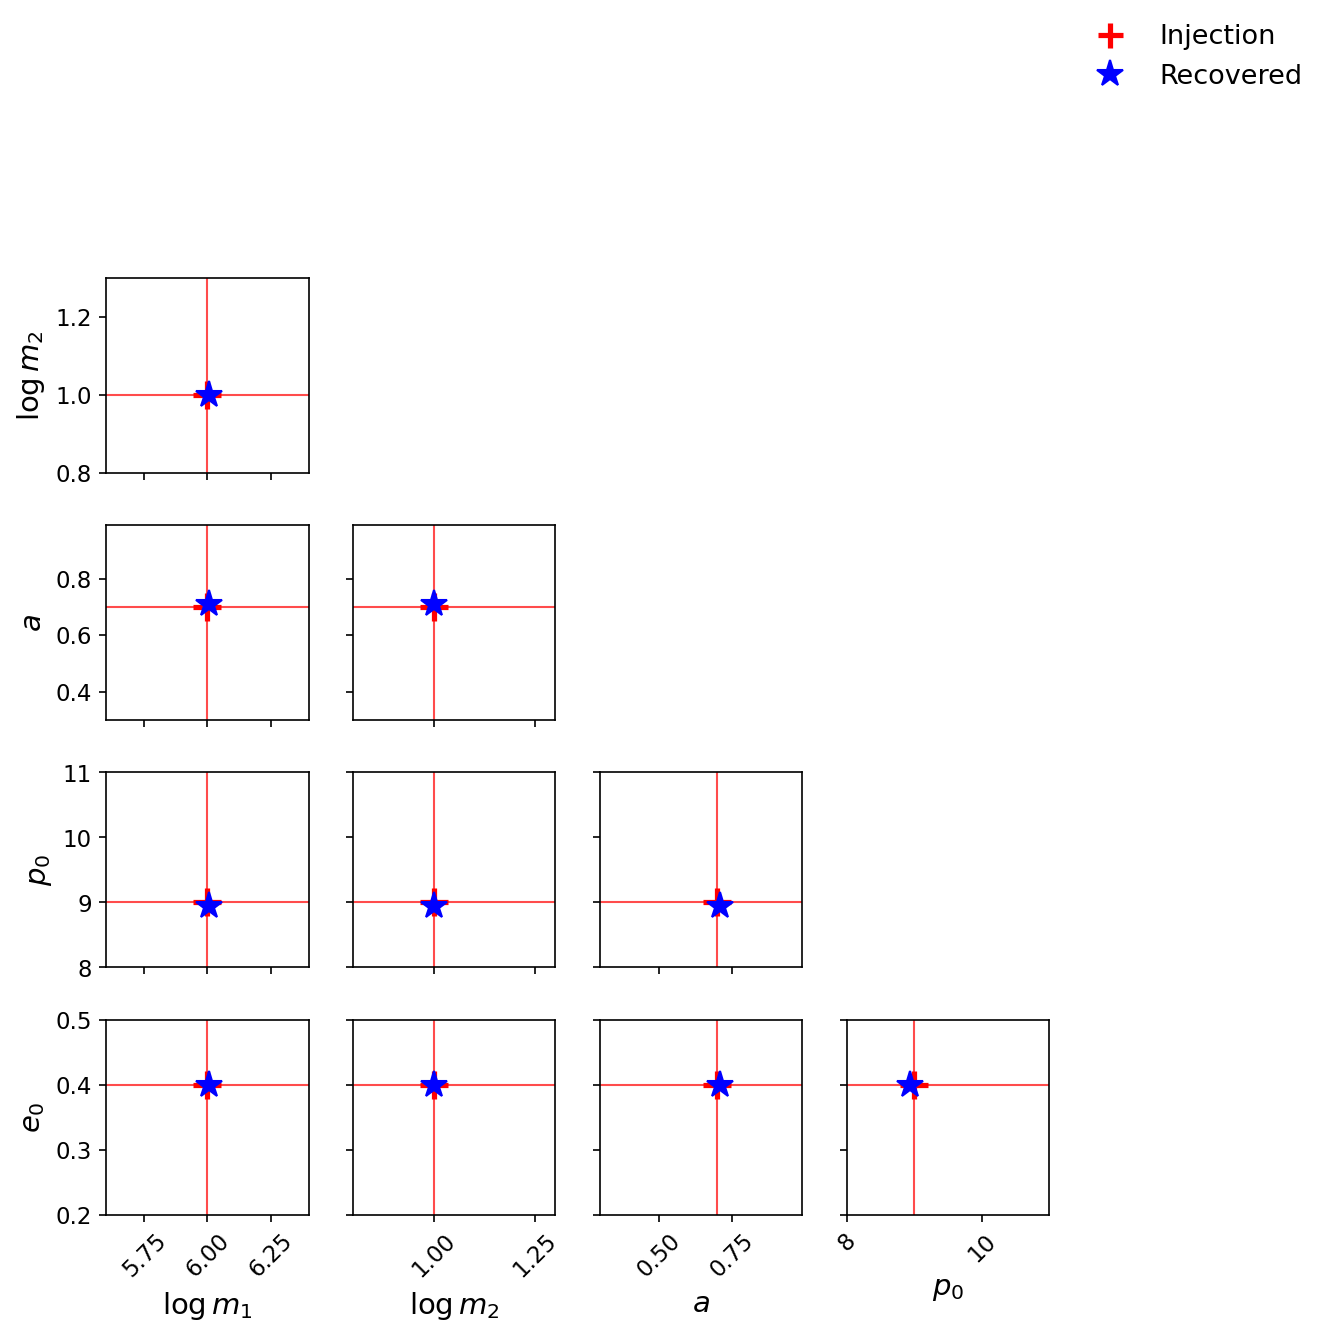

In [5]:

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

plt.rcParams.update({
    'font.size': 13, 'axes.labelsize': 14,
    'xtick.labelsize': 11, 'ytick.labelsize': 11,
    'figure.dpi': 150, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
})

labels = [r'$\log m_1$', r'$\log m_2$', r'$a$', r'$p_0$', r'$e_0$']
ndim = len(labels)

param_true = np.asarray(param_true).ravel()
maxld_pt1  = np.asarray(maxld_pt1).ravel()

# full prior width per parameter: param_ranges = [(lo, hi), ...]
param_ranges = [tuple(r) for r in param_ranges]

fig, axes = plt.subplots(ndim, ndim, figsize=(9, 9))

for i in range(ndim):
    for j in range(ndim):
        ax = axes[i, j]
        if j >= i:                       # blank diagonal + upper triangle
            ax.set_visible(False)
            continue

        # injection crosshairs + marker
        ax.axvline(param_true[j], color='red', lw=1.0, alpha=0.7, zorder=1)
        ax.axhline(param_true[i], color='red', lw=1.0, alpha=0.7, zorder=1)
        ax.plot(param_true[j], param_true[i], '+', color='red',
                ms=13, mew=2.5, zorder=3)

        # recovered MAP point
        ax.plot(maxld_pt1[j], maxld_pt1[i], '*', color='blue',
                ms=13, zorder=4)

        # full prior width
        ax.set_xlim(*param_ranges[j])
        ax.set_ylim(*param_ranges[i])

        if j == 0:
            ax.set_ylabel(labels[i])
        else:
            ax.set_yticklabels([])
        if i == ndim - 1:
            ax.set_xlabel(labels[j])
            ax.tick_params(axis='x', rotation=45)
        else:
            ax.set_xticklabels([])

handles = [
    Line2D([0], [0], color='red',  marker='+', ls='', ms=12, mew=2.5, label='Injection'),
    Line2D([0], [0], color='blue', marker='*', ls='', ms=13,          label='Recovered'),
]
fig.legend(handles=handles, loc='upper right', frameon=False, fontsize=13)
fig.tight_layout()

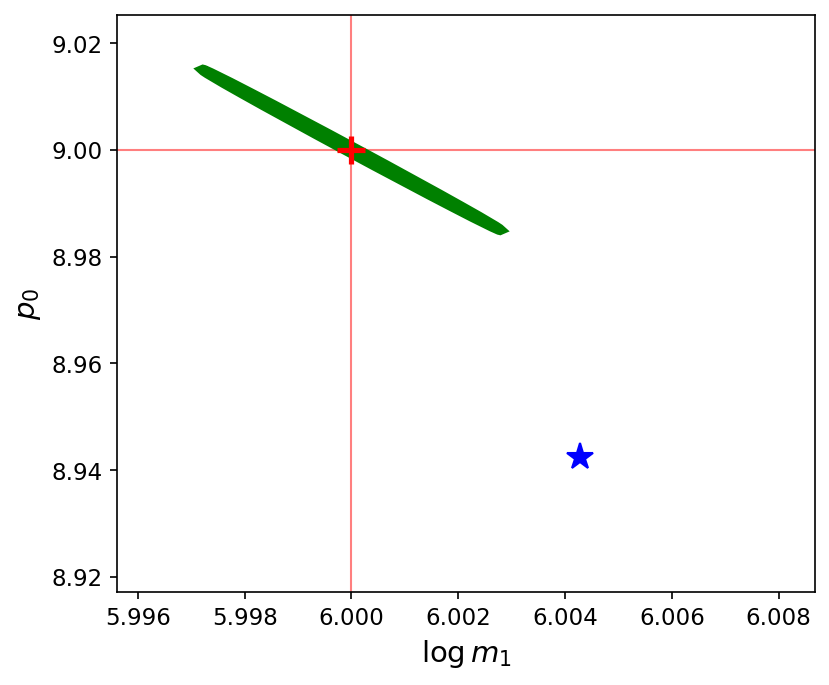

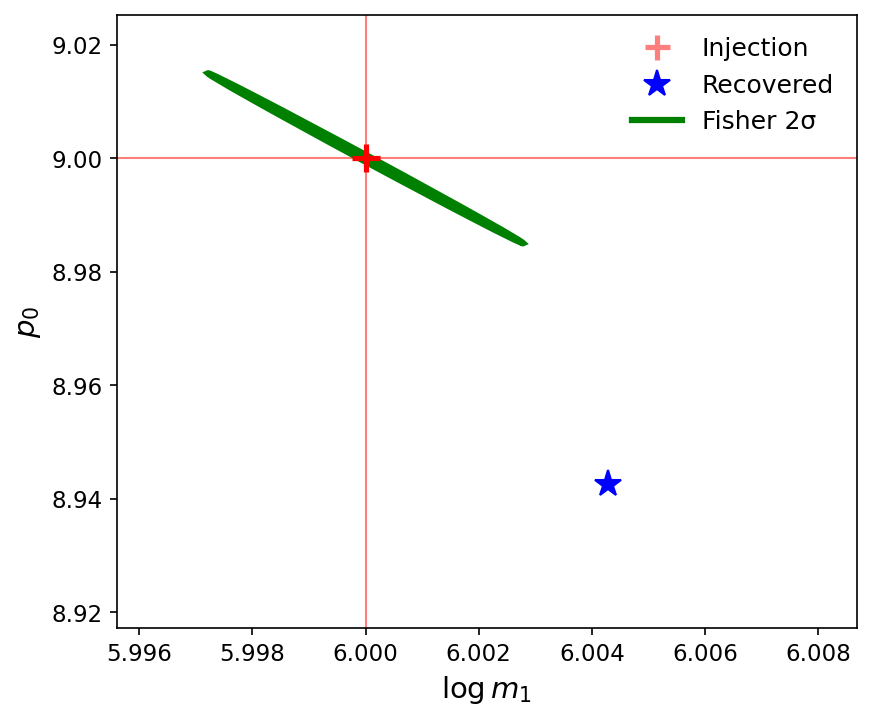

In [7]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Ellipse

with open('/nfs/home/svu/e1498138/localgit/FEWNEW/work/cov_matrix_snr30_1yr.pkl', 'rb') as f:
    cov = pickle.load(f)

def draw_cov_ellipse(ax, cx, cy, cov2d, n_sigma=1, **kwargs):
    vals, vecs = np.linalg.eigh(cov2d)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]
    angle = np.degrees(np.arctan2(*vecs[:, 0][::-1]))
    ell = Ellipse(xy=(cx, cy),
                width=2 * n_sigma * np.sqrt(vals[0]),
                height=2 * n_sigma * np.sqrt(vals[1]),
                angle=angle, **kwargs)
    ax.add_patch(ell)

_pt  = np.asarray(param_true).ravel()
_map = np.asarray(maxld_pt1).ravel()
sigs = np.sqrt(np.diag(cov))

j, i = 0, 3   # x = log10(m1), y = p0
cov2d = cov[np.ix_([j, i], [j, i])]

xlo = min(_pt[j], _map[j]);  xhi = max(_pt[j], _map[j])
ylo = min(_pt[i], _map[i]);  yhi = max(_pt[i], _map[i])
xpad = (xhi - xlo) * 0.05 + 3 * sigs[j]
ypad = (yhi - ylo) * 0.05 + 3 * sigs[i]

fig, ax = plt.subplots(figsize=(6, 5))
ax.set_xlim(xlo - xpad, xhi + xpad)
ax.set_ylim(ylo - ypad, yhi + ypad)

ax.axvline(_pt[j], color='red', lw=1.0, alpha=0.5, zorder=1)
ax.axhline(_pt[i], color='red', lw=1.0, alpha=0.5, zorder=1)
ax.plot(_pt[j], _pt[i], '+', color='red', ms=13, mew=2.5, zorder=3)
ax.plot(_map[j], _map[i], '*', color='blue', ms=13, zorder=4)

draw_cov_ellipse(ax, _pt[j], _pt[i], cov2d,
                n_sigma=2, facecolor='none', edgecolor='green', lw=5, zorder=2)

ax.set_xlabel(r'$\log m_1$')
ax.set_ylabel(r'$p_0$')
sigs = np.sqrt(np.diag(cov))

j, i = 0, 3   # x = log10(m1), y = p0
cov2d = cov[np.ix_([j, i], [j, i])]

xlo = min(_pt[j], _map[j]);  xhi = max(_pt[j], _map[j])
ylo = min(_pt[i], _map[i]);  yhi = max(_pt[i], _map[i])
xpad = (xhi - xlo) * 0.05 + 3 * sigs[j]
ypad = (yhi - ylo) * 0.05 + 3 * sigs[i]

fig, ax = plt.subplots(figsize=(6, 5))
ax.set_xlim(xlo - xpad, xhi + xpad)
ax.set_ylim(ylo - ypad, yhi + ypad)

ax.axvline(_pt[j], color='red', lw=1.0, alpha=0.5, zorder=1)
ax.axhline(_pt[i], color='red', lw=1.0, alpha=0.5, zorder=1)
ax.plot(_pt[j], _pt[i], '+', color='red', ms=13, mew=2.5, zorder=3)
ax.plot(_map[j], _map[i], '*', color='blue', ms=13, zorder=4)

draw_cov_ellipse(ax, _pt[j], _pt[i], cov2d,
                n_sigma=2, facecolor='none', edgecolor='green', lw=3, zorder=2)

ax.set_xlabel(r'$\log  m_1$')
ax.set_ylabel(r'$p_0$')

legend_handles = [
    Line2D([0], [0], color='red',   marker='+', ls='', ms=12, mew=2.5, alpha=0.5, label='Injection'),
    Line2D([0], [0], color='blue',  marker='*', ls='', ms=13,           label='Recovered'),
    Line2D([0], [0], color='green', ls='-',  lw=3,                      label='Fisher 2σ'),
]
ax.legend(handles=legend_handles, frameon=False, fontsize=12)
plt.tight_layout()
plt.show()

In [2]:
sampler = parismc.Sampler.load_state('./search/intrinsic_ffunc_3mth_snr32_paris2_2/sampler_state.pkl')

In [3]:
samples, weights = sampler.get_samples_with_weights(flatten=True)

In [4]:
proc_pt = sampler.searched_points_list
proc_pt

[array([[ 0.54127866,  0.64523908,  0.56906367,  0.34914906,  0.38973097],
        [ 3.68423362, -0.95212163, -1.54225742,  4.1862093 ,  2.68128516],
        [-1.83081466,  0.3112313 , -2.71954214,  2.41899412, -3.54954827],
        ...,
        [ 0.49762477,  0.3942457 ,  0.57667177,  0.33801216,  0.67296472],
        [ 0.46865151,  0.37520418,  0.50564436,  0.43069639,  0.69968956],
        [ 0.53298297,  0.41880976,  0.66191974,  0.22677707,  0.63928536]],
       shape=(100000, 5))]

In [5]:
logden_list = sampler.searched_log_densities_list
logden_list

[array([  8.66187251,         -inf,         -inf, ..., 517.7481135 ,
        288.98628297, 383.87366128], shape=(100000,))]

In [6]:
maxld_pt1 = prior_transform(proc_pt[0][np.argmax(logden_list)].reshape(1, -1))
maxld_pt1

array([[6.00428558, 1.00036002, 0.7101336 , 8.94251488, 0.3992983 ]])

In [7]:
log_density(maxld_pt1)

array([5.9048406])

In [8]:
log_density(maxld_pt1)/S

array([5.9048406])

In [ ]:
logm1_pt, logm2_pt, a_pt, p0_pt, e0_pt = maxld_pt1[0]

h_pt1 = waveform_gen_comb(
    10**logm1_pt, 10**logm2_pt, a_pt, p0_pt, e0_pt,
    xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0,
    dt=dt, T=T
)

In [10]:
gwf.rhostat(h_pt1)

array(5.95881875)

In [11]:
gwf.Xstat_timemax(data, h_pt1), gwf.Xstat(data, h_pt1)

(array(5.93643792), array(4.92331137))

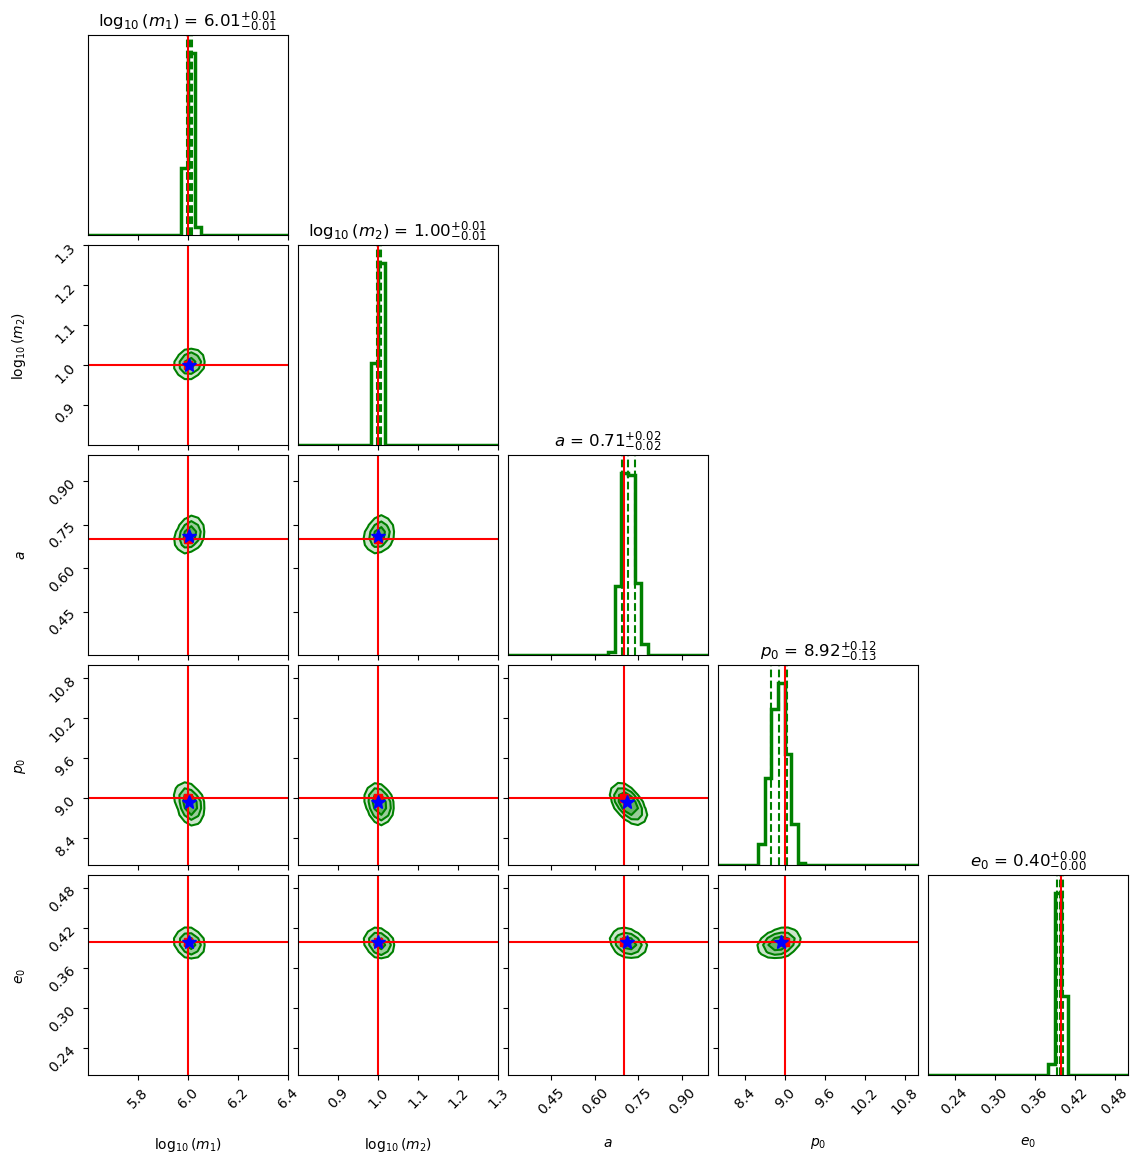

In [13]:
import corner
labels = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$']
fig = corner.corner(
    samples,
    weights=weights,
    labels=labels,
    truths=param_true,
    truth_color='red',
    color='green',
    show_titles=True,
    label_kwargs={"fontsize": 10},
    title_kwargs={"fontsize": 12},
    quantiles=[0.16, 0.5, 0.84],
    smooth=True,
    bins=30,
    plot_datapoints=False,
    hist_kwargs={"density": True, 'linewidth': 2.5},
    linewidth=2.5,
    fill_contours=True,
    range = param_ranges
)

corner.overplot_points(fig, maxld_pt1.reshape(1, -1), 
                       color='blue', marker='*', ms=10, 
                       reverse=False)




In [19]:
all_pts_u   = proc_pt[0]      
all_logden  = logden_list[0] 

mask = np.isfinite(all_logden) & (all_logden >= 5.8)
filtered_pts    = prior_transform(all_pts_u[mask])  
filtered_logden = all_logden[mask]
print(f"Kept {mask.sum()} / {len(mask)} points (logden >= 5.8)")

# exp-weights proportional to likelihood
w = np.exp(filtered_logden - filtered_logden.max())
w /= w.sum()


true_pt    = np.array(param_true)
ranges_arr = np.array([r[1] - r[0] for r in param_ranges])
diffs      = (filtered_pts - true_pt) / ranges_arr
dists      = np.linalg.norm(diffs, axis=1)
closest_idx = np.argmin(dists)
closest_pt  = filtered_pts[closest_idx]

print(f"True point:    {true_pt}")
print(f"Closest point: {closest_pt}")
print(f"Normalised distance: {dists[closest_idx]:.4f}")




Kept 87054 / 100000 points (logden >= 5.8)
True point:    [6.  1.  0.7 9.  0.4]
Closest point: [6.00000764 1.00002219 0.70004535 8.99940022 0.39998947]
Normalised distance: 0.0002


In [22]:
log_density([closest_pt])

array([5.80129587])

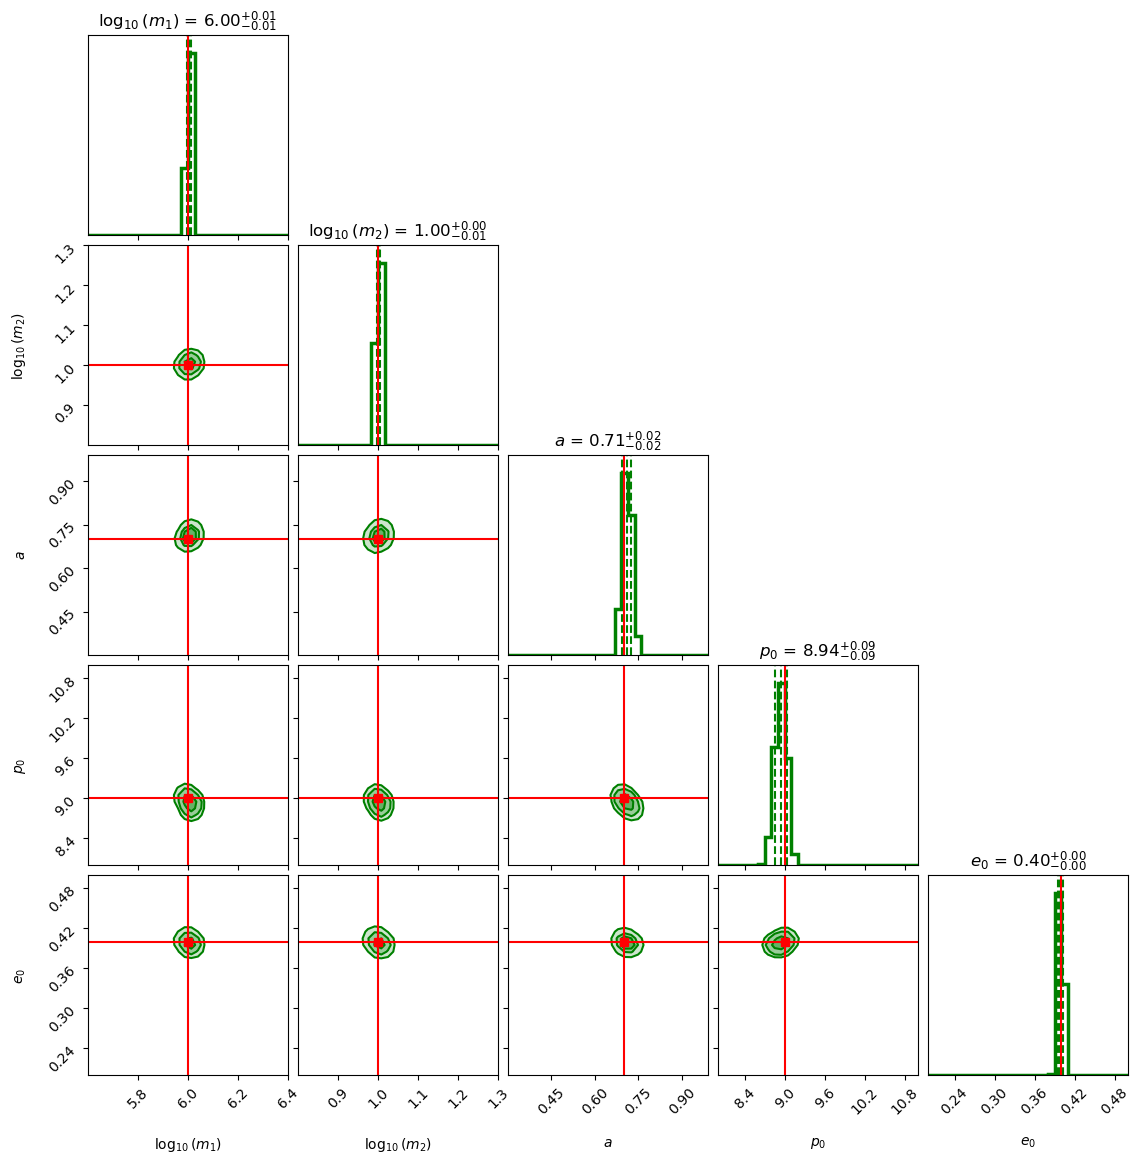

In [20]:
fig = corner.corner(
    filtered_pts,
    weights=w,
    labels=labels,
    truths=param_true,
    truth_color='red',
    color='green',
    show_titles=True,
    label_kwargs={"fontsize": 10},
    title_kwargs={"fontsize": 12},
    quantiles=[0.16, 0.5, 0.84],
    smooth=True,
    bins=30,
    plot_datapoints=False,
    hist_kwargs={"density": True, 'linewidth': 2.5},
    linewidth=2.5,
    fill_contours=True,
    range=param_ranges
)

# connection plot

In [33]:
proc1_maxld_pt = maxld_pt1.copy().reshape(1,-1)
proc1_maxld_pt

array([[6.00428558, 1.00036002, 0.7101336 , 8.94251488, 0.3992983 ]])

In [34]:
# connect two highest logden pts
#NOTE: change here for closest point vs max ld pt
# proc1_maxld_pt_1d = proc1_maxld_pt[0] 
proc1_maxld_pt_1d = proc1_maxld_pt[0]
true_pt = np.array(param_true)

# NOTE: connecting only till the true/target pt 
n_points = 50
t_values = np.linspace(0, 1, n_points)  # extend beyond each endpoint
line_points_proc1 = proc1_maxld_pt_1d[:, np.newaxis] + t_values * (true_pt - proc1_maxld_pt_1d)[:, np.newaxis]


In [35]:
logden_theory_proc1 = []
logden_theory_proc1.append(log_density(np.array(line_points_proc1).T))


In [36]:
logden_theory_proc1 = np.array(logden_theory_proc1).flatten()


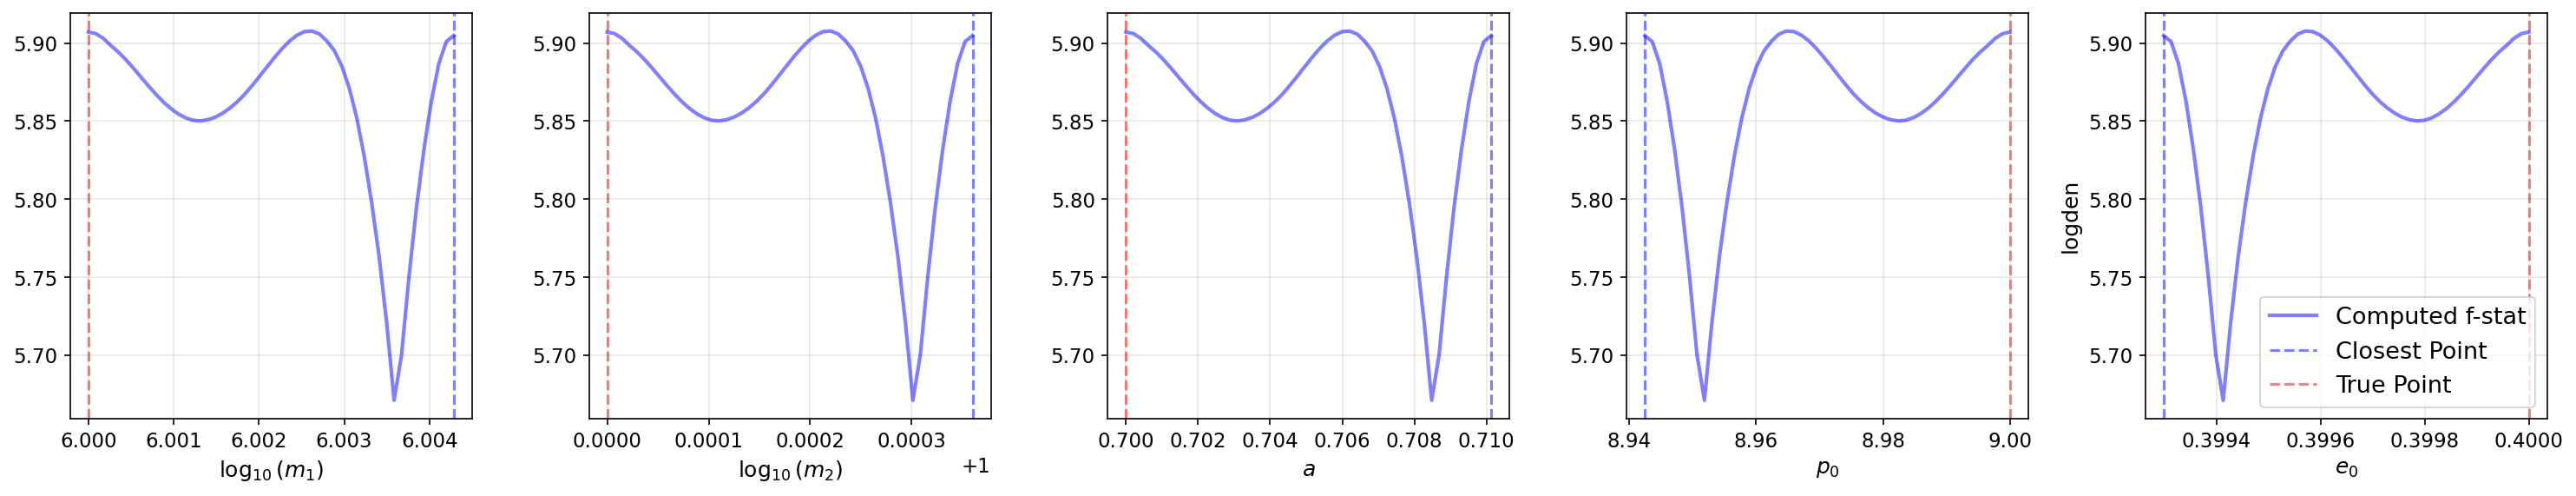

In [37]:
fig_1d, axs_1d = plt.subplots(1, 5, figsize=(20, 4))
labels = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$']
plt.ylabel('logden', fontsize=12)
for dim in range(5):
    ax = axs_1d[dim]

    # Plot theoretical log-density
    ax.plot(line_points_proc1[dim], logden_theory_proc1, '-', 
            color='blue', alpha=0.5, linewidth=2, label='Computed f-stat')


    # Mark the max likelihood points
    ax.axvline(proc1_maxld_pt_1d[dim], color='blue', linestyle='--', 
               alpha=0.5, label=f'Closest Point')
    ax.axvline(param_true[dim], color='red', linestyle='--', 
               alpha=0.5, label='True Point')
    
    ax.set_xlabel(labels[dim], fontsize=12)
    # ax.set_ylabel('logden', fontsize=12)
    ax.grid(True, alpha=0.3)

plt.legend()
plt.tight_layout()


In [38]:
data_f = gwf.freq_wave(loglike_obj.signal)   # precompute ONCE (data already contains signal+noise)

def loglike(params):
    params = np.asarray(params)
    log_likes = np.zeros(params.shape[0])
    for i in range(params.shape[0]):
        logm1, logm2, a_i, p0_i, e0_i = params[i]
        try:
            htemp = waveform_gen_comb(10**logm1, 10**logm2, a_i, p0_i, e0_i,
                                      xI0, dist, qS, phiS, qK, phiK,
                                      Phi_phi0, Phi_theta0, Phi_r0, T=T, dt=dt)
            res_f = gwf.freq_wave(htemp) - data_f
            ip = gwf.inner(res_f, res_f).get()
            log_likes[i] = -np.inf if (np.isnan(ip) or np.isinf(ip)) else -0.5 * ip
        except Exception:
            log_likes[i] = -np.inf
    return log_likes


In [39]:
loglike_proc1 = []
loglike_proc1.append(loglike(np.array(line_points_proc1).T))


In [40]:
loglike_proc1 = np.array(loglike_proc1).flatten()


In [41]:
loglike_proc1

array([-20.39143347, -18.17305727, -16.03494237, -13.9997625 ,
       -12.08617927, -10.30854609,  -8.67716979,  -7.19852303,
        -5.87545887,  -4.70762525,  -3.69191707,  -2.82280635,
        -2.09294442,  -1.49334981,  -1.01403414,  -0.64414553,
        -0.37245628,  -0.18751768,  -0.07797579,  -0.03274019,
        -0.04112095,  -0.09296891,  -0.17876481,  -0.28966043,
        -0.41757178,  -0.55511958,  -0.69571196,  -0.83350396,
        -0.96338822,  -1.08099129,  -1.18263879,  -1.26532725,
        -1.32675103,  -1.36522336,  -1.37970413,  -1.36982703,
        -1.33579675,  -1.27846856,  -1.19934945,  -1.10058906,
        -0.98498167,  -0.85603085,  -0.71791233,  -0.57557195,
        -0.4346095 ,  -0.30142867,  -0.18315996,  -0.08767478,
        -0.02353701,  -0.        ])

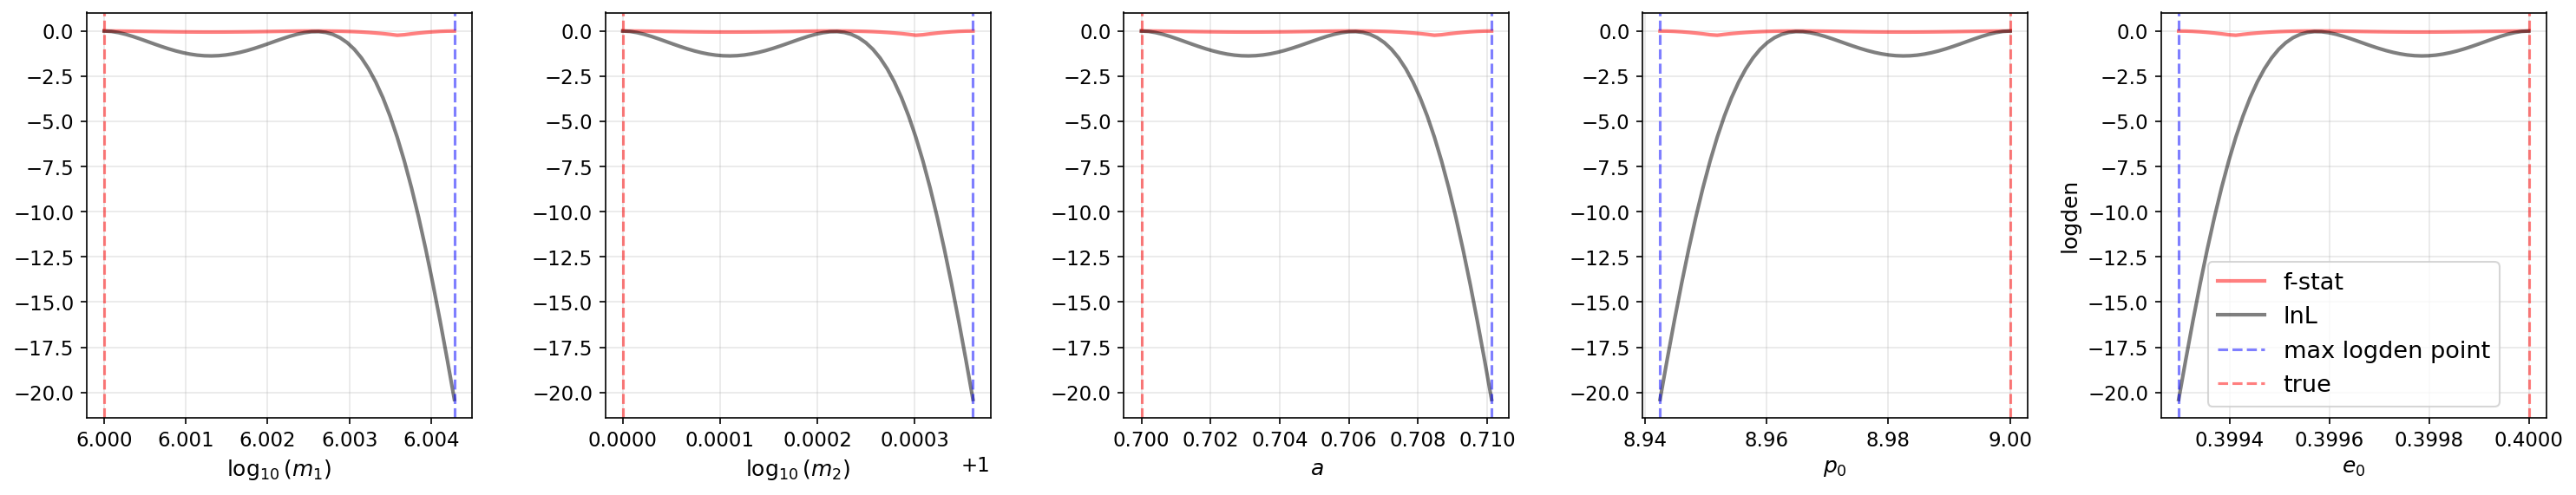

In [42]:
fig_1d, axs_1d = plt.subplots(1, 5, figsize=(20, 4))
labels = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$']
plt.ylabel('logden', fontsize=12)
for dim in range(5):
    ax = axs_1d[dim]

    # Plot theoretical log-density
    ax.plot(line_points_proc1[dim], logden_theory_proc1 - np.max(logden_theory_proc1),
            color='red', alpha=0.5, lw=2, label='f-stat')
    ax.plot(line_points_proc1[dim], loglike_proc1 ,
            color='black', alpha=0.5, lw=2, label='lnL')



    # Mark the max likelihood points
    ax.axvline(proc1_maxld_pt_1d[dim], color='blue', linestyle='--', 
               alpha=0.5, label=f'max logden point')
    ax.axvline(param_true[dim], color='red', linestyle='--', 
               alpha=0.5, label='true')
    
    ax.set_xlabel(labels[dim], fontsize=12)
    # ax.set_ylabel('logden', fontsize=12)
    ax.grid(True, alpha=0.3)

plt.legend()
plt.tight_layout()
